<a href="https://colab.research.google.com/github/Gursharan-Reddy/InterSpark-Data-Science-Internship/blob/main/Task1_Zomato_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/zomato")

print("Path to dataset files:", path)

100%|██████████| 5.28M/5.28M [00:00<00:00, 148MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/zomato/versions/1


Using Colab cache for faster access to the 'zomato' dataset.
Dataset loaded successfully!

--- Basic EDA Before Cleaning ---
Dataset Shape: (56252, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  objec

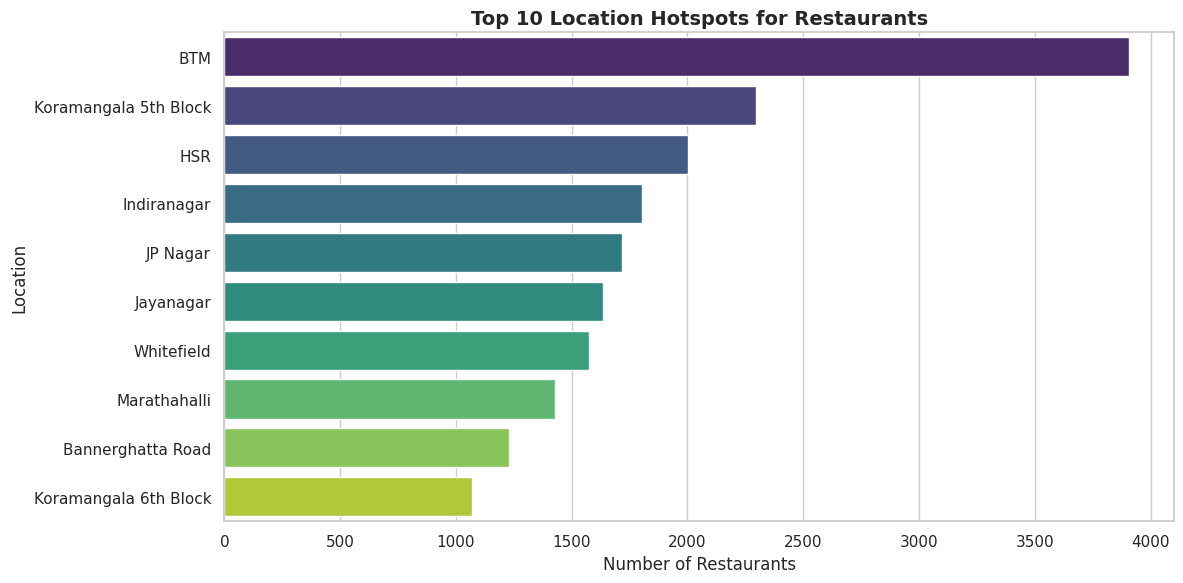

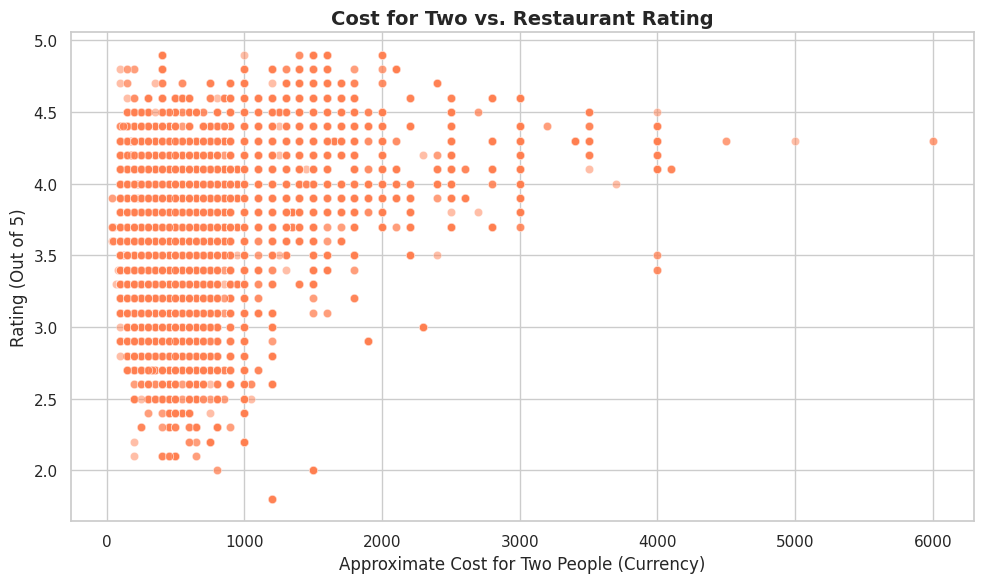

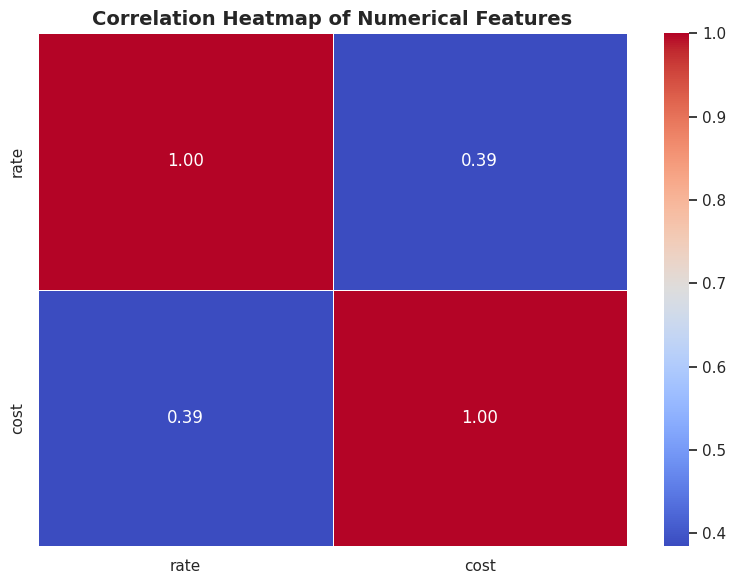

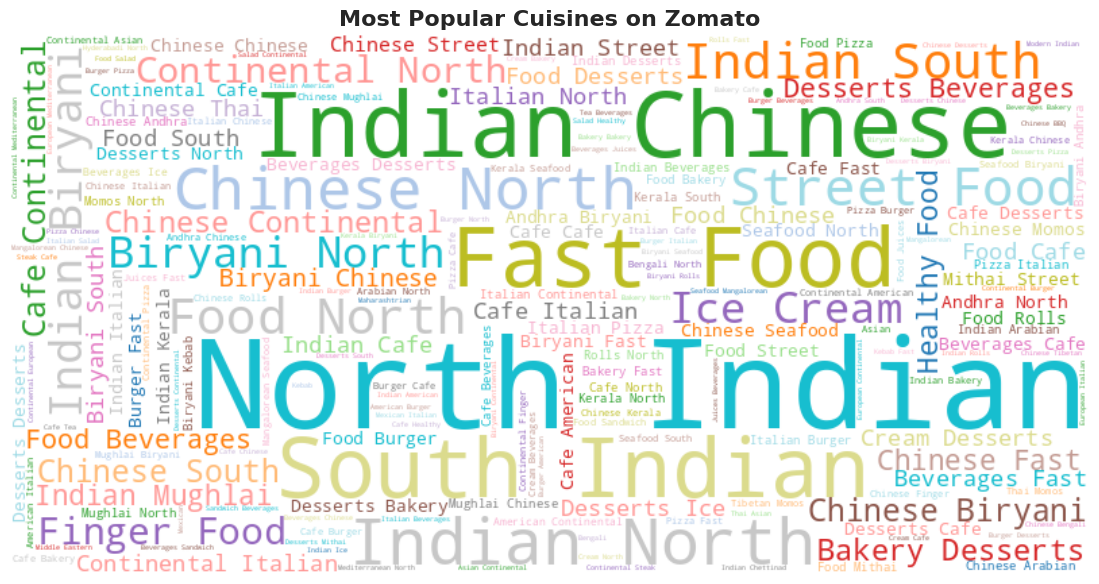

In [ ]:
# 1. IMPORT LIBRARIES AND DATASET
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

# Download and load the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("bhanupratapbiswas/zomato")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print("Dataset loaded successfully!\n")
else:
    print("Error: No CSV file found.")

# ---------------------------------------------------------
# 2. BASIC EDA & DATA CLEANING
print("--- Basic EDA Before Cleaning ---")
print(f"Dataset Shape: {df.shape}")
print(df.info())

# Drop columns that aren't strictly necessary for our specific analysis to save memory
columns_to_drop = ['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Rename complex columns for easier access
df = df.rename(columns={'approx_cost(for two people)': 'cost', 'listed_in(type)': 'type'})

# Clean the 'rate' column safely (Handles '/5', 'NEW', '-', and corrupted text like '\nTop floor')
def clean_rate(value):
    if pd.isna(value) or value == 'NEW' or value == '-':
        return np.nan

    # Extract the part before '/'
    value = str(value).split('/')[0].strip()

    # Safely try to convert to float
    try:
        return float(value)
    except ValueError:
        return np.nan # If it's random text, mark as missing data

df['rate'] = df['rate'].apply(clean_rate)

# Clean the 'cost' column safely (Handles commas and potential corrupted text)
def clean_cost(value):
    if pd.isna(value):
        return np.nan

    # Remove commas
    value = str(value).replace(',', '').strip()

    # Safely try to convert to float
    try:
        return float(value)
    except ValueError:
        return np.nan

df['cost'] = df['cost'].apply(clean_cost)

# Drop rows with missing values in critical columns to ensure clean visualizations
df = df.dropna(subset=['rate', 'cost', 'location', 'cuisines'])

print("\n--- EDA After Cleaning ---")
print(f"Cleaned Dataset Shape: {df.shape}")
print(df.describe())

# ---------------------------------------------------------
# 3. VISUALIZATIONS

# Set visual style
sns.set_theme(style="whitegrid")

# Visualization 1: Location Hotspots (Top 10 Locations)
plt.figure(figsize=(12, 6))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Location Hotspots for Restaurants', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

# Visualization 2: Price vs Rating (Scatterplot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost', y='rate', data=df, alpha=0.5, color='coral')
plt.title('Cost for Two vs. Restaurant Rating', fontsize=14, fontweight='bold')
plt.xlabel('Approximate Cost for Two People (Currency)')
plt.ylabel('Rating (Out of 5)')
plt.tight_layout()
plt.show()

# Visualization 3: Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualization 4: Popular Cuisines WordCloud
plt.figure(figsize=(12, 6))
# Combine all cuisines into a single large string
cuisine_text = " ".join(cuisine for cuisine in df['cuisines'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate(cuisine_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most Popular Cuisines on Zomato', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()